# Relatório: Descoberta de Letras Ocultas

Este notebook documenta o processo de recuperação de letras ocultas numa imagem corrompida por ruído. O processo utiliza técnicas de processamento de imagem, incluindo filtragem espacial, filtragem espetral e segmentação.

## Bibliotecas Utilizadas
- `cv2` (OpenCV): Para operações de processamento de imagem e filtros espaciais.
- `numpy`: Para manipulação de matrizes e Transformada de Fourier (FFT).
- `matplotlib.pyplot`: Para visualização das imagens ao longo do processo.
- `os`: Para gestão de diretórios de output.
- `pytesseract`: (Opcional) Para validação final da leitura do texto através de OCR.

In [73]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

try:
    import pytesseract
except ImportError:
    print("Aviso: pytesseract não está instalado. A validação final por OCR não funcionará. Para o utilizar, corre 'pip install pytesseract'")


Aviso: pytesseract não está instalado. A validação final por OCR não funcionará. Para o utilizar, corre 'pip install pytesseract'


## 1. Configuração de Parâmetros (Variáveis 'k')
Todas as variáveis das funções do OpenCV e lógicas auxiliares são definidas aqui. Isto facilita a afinação dos parâmetros da pipeline.

In [74]:
# Caminhos dos ficheiros
INPUT_IMAGE_PATH = '../assets/Letters-noisy.png'
OUTPUT_DIR = '../output/'

# Criar diretório de output se não existir
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ==========================================
# PARÂMETROS - FILTRAGEM ESPETRAL (Ruído Periódico)
# ==========================================
# Iterações para o Notch Filter Gaussiano.
# 'threshold_ratio': Percentagem da magnitude máxima do espetro (ex: 0.80 = 80%).
# 'radius': Raio do filtro Gaussiano Notch a aplicar nesse pico.
NOTCH_PASSES = [
    {'threshold_ratio': 0.80, 'radius': 7.0}, # Passagem 1: Picos mais altos com raio maior
    {'threshold_ratio': 0.70, 'radius': 2.0}  # Passagem 2: Picos secundários com raio menor
]
NOTCH_CENTER_PROTECTION = 4 # Raio de proteção em torno da componente DC (centro) para preservar a iluminação base

# ==========================================
# PARÂMETROS - FILTRAGEM ESPACIAL (Ruído Salt & Pepper)
# ==========================================
MEDIAN_KERNEL_SIZE = 3 # Tamanho do kernel para o filtro de Mediana (deve ser ímpar: 3, 5, 7...)

# ==========================================
# PARÂMETROS - AUMENTO DE CONTRASTE (CLAHE)
# ==========================================
CLAHE_CLIP_LIMIT = 6.0 # Limiar de contraste para o CLAHE (valores maiores dão mais contraste)
CLAHE_TILE_GRID_SIZE = (4, 4) # Tamanho da grelha para equalização local

# ==========================================
# PARÂMETROS - SEGMENTAÇÃO / BINARIZAÇÃO
# ==========================================
BIN_THRESH_VALUE = 110 # Valor limite (Threshold) para a binarização manual (0-255)
BIN_MAX_VALUE = 255    # Valor a atribuir aos píxeis que passam o limite

# ==========================================
# PARÂMETROS - EXTRAÇÃO DE CONTORNOS
# ==========================================
CANNY_THRESH1 = 50  # Limite inferior do detector de bordas de Canny
CANNY_THRESH2 = 150 # Limite superior do detector de bordas de Canny


## 2. Carregar Imagem Original

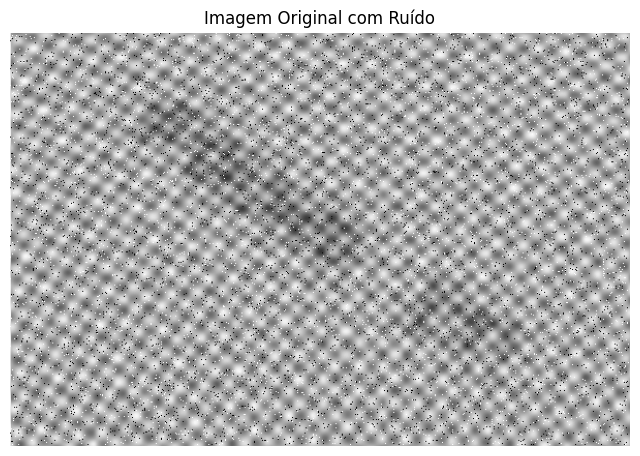

In [75]:
img_original = cv2.imread(INPUT_IMAGE_PATH, cv2.IMREAD_GRAYSCALE)
if img_original is None:
    raise ValueError(f"Erro: Não foi possível carregar a imagem em {INPUT_IMAGE_PATH}")

plt.figure(figsize=(8, 6))
plt.imshow(img_original, cmap='gray')
plt.title('Imagem Original com Ruído')
plt.axis('off')
plt.show()


## 3. Passo 1: Remover Ruído Periódico (Filtragem Espetral)
Usamos a Transformada de Fourier (FFT) para identificar picos de frequência anormais que representam o ruído periódico.
De seguida, iteramos sobre as configurações definidas em `NOTCH_PASSES` para aplicar filtros Gaussianos tipo Notch. O uso da variação de raios e limiares por passagem ajuda a eliminar estes picos de forma mais suave e orgânica face a um bloqueio rígido.

Passagem 1: Threshold=80.0%, Raio=7.0 aplicados na máscara.
Passagem 2: Threshold=70.0%, Raio=2.0 aplicados na máscara.


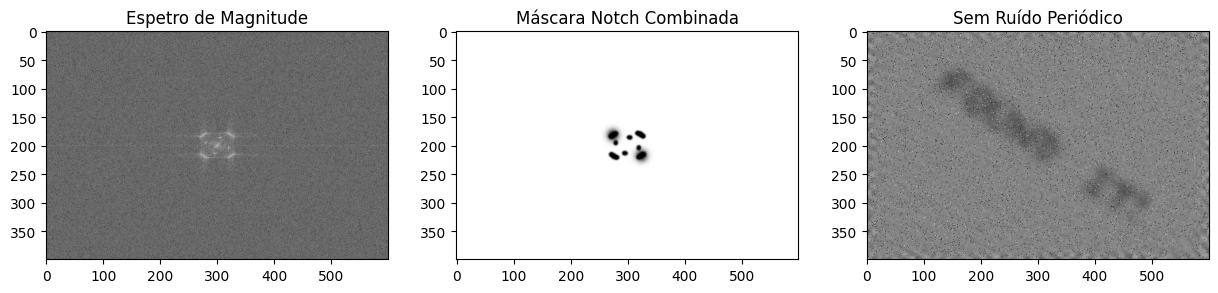

In [76]:
def create_gaussian_notch_mask(shape, center, radius):
    rows, cols = shape
    u = np.arange(rows)
    v = np.arange(cols)
    u, v = np.meshgrid(u, v, indexing='ij')
    
    d_square = (u - center[0])**2 + (v - center[1])**2
    mask = 1.0 - np.exp(-d_square / (2 * (radius**2)))
    return mask

dft = np.fft.fft2(img_original.astype(np.float32))
dft_shifted = np.fft.fftshift(dft)
magnitude_spectrum = 20 * np.log(np.abs(dft_shifted) + 1)

rows, cols = img_original.shape
crow, ccol = rows // 2, cols // 2
combined_mask = np.ones((rows, cols), np.float32)
max_mag = np.max(magnitude_spectrum)

# Aplicar Notch Filters iterativamente (1st pass, 2nd pass...)
for i, pass_config in enumerate(NOTCH_PASSES):
    thresh_ratio = pass_config['threshold_ratio']
    radius = pass_config['radius']
    
    thresh = max_mag * thresh_ratio
    peaks = np.where(magnitude_spectrum > thresh)
    
    pass_mask = np.ones((rows, cols), np.float32)
    for r, c in zip(peaks[0], peaks[1]):
        # Não filtrar o componente DC (iluminação da imagem)
        if abs(r - crow) > NOTCH_CENTER_PROTECTION or abs(c - ccol) > NOTCH_CENTER_PROTECTION:
            notch = create_gaussian_notch_mask((rows, cols), (r, c), radius)
            pass_mask *= notch
            
    combined_mask *= pass_mask
    print(f"Passagem {i+1}: Threshold={thresh_ratio*100}%, Raio={radius} aplicados na máscara.")

fshift_filtered = dft_shifted * combined_mask
img_back = np.fft.ifft2(np.fft.ifftshift(fshift_filtered))
img_periodic_removed = np.abs(img_back)
img_periodic_removed = cv2.normalize(img_periodic_removed, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

# Guardar
cv2.imwrite(os.path.join(OUTPUT_DIR, '1_periodic_removed.png'), img_periodic_removed)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1), plt.imshow(magnitude_spectrum, cmap='gray'), plt.title('Espetro de Magnitude')
plt.subplot(1, 3, 2), plt.imshow(combined_mask, cmap='gray'), plt.title('Máscara Notch Combinada')
plt.subplot(1, 3, 3), plt.imshow(img_periodic_removed, cmap='gray'), plt.title('Sem Ruído Periódico')
plt.show()


## 4. Passo 2: Remover Ruído Espacial (Filtro Bilateral)
Após a limpeza no domínio da frequência, a imagem ainda apresenta ruído residual e alguma textura de fundo. 
Embora o filtro de Mediana seja o método tradicional para ruído extremo tipo "sal e pimenta", optámos por utilizar o **Filtro Bilateral**. Esta técnica é excecional a suavizar o ruído e a homogeneizar as texturas do fundo, garantindo simultaneamente que as bordas (os limites nítidos e os cantos das letras) são estritamente preservadas e não ficam desfocadas.

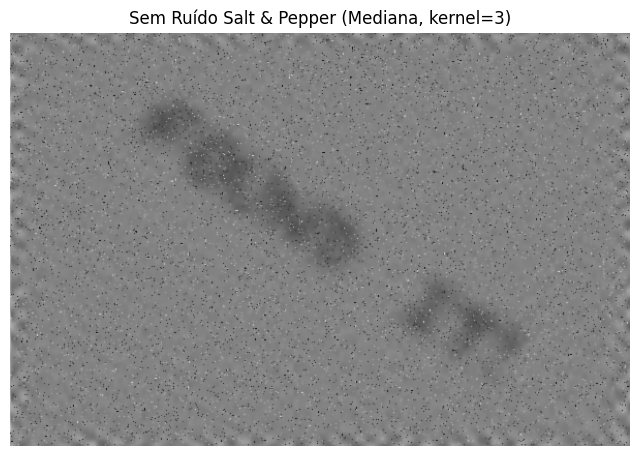

In [77]:
# Aplicação do Filtro Bilateral
# d (diâmetro) = MEDIAN_KERNEL_SIZE, sigmaColor = 75, sigmaSpace = 75
img_denoised = cv2.bilateralFilter(img_periodic_removed, MEDIAN_KERNEL_SIZE, 75, 75)

# Guardar
cv2.imwrite(os.path.join(OUTPUT_DIR, '2_salt_pepper_removed.png'), img_denoised)

plt.figure(figsize=(8, 6))
plt.imshow(img_denoised, cmap='gray')
plt.imshow(img_denoised, cmap='gray', vmin=0, vmax=255)
plt.title(f'Sem Ruído Salt & Pepper (Mediana, kernel={MEDIAN_KERNEL_SIZE})')
plt.axis('off')
plt.show()


## 5. Visualização do Histograma
Para percebermos a distribuição dos níveis de cinzento na imagem após a remoção de ruído, analisamos o histograma. O plot confirma como os dados estão agrupados, o que ajuda a decidir as técnicas de contraste a aplicar.

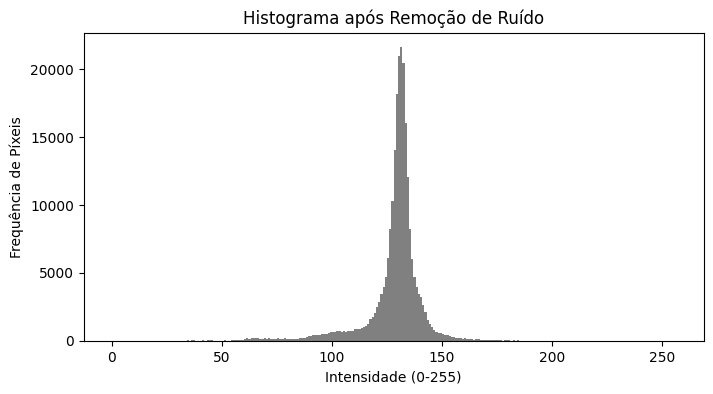

In [78]:
plt.figure(figsize=(8, 4))
plt.hist(img_denoised.ravel(), bins=256, range=[0,256], color='gray')
plt.title('Histograma após Remoção de Ruído')
plt.xlabel('Intensidade (0-255)')
plt.ylabel('Frequência de Píxeis')
plt.show()


## 6. Passo 3: Aumento de Contraste Local (CLAHE)
Como as letras estão num tom cinzento escuro concentrado no centro da imagem (criando o efeito de um "blur preto"), aplicar uma binarização direta resulta num bloco sólido.
Para resolver isso, usamos o CLAHE (Contrast Limited Adaptive Histogram Equalization). O CLAHE melhora o contraste localmente (por grelhas, configuradas na variável `CLAHE_TILE_GRID_SIZE`), distribuindo melhor os níveis de cinzento e evidenciando as formas orgânicas das letras (como o F e o N).

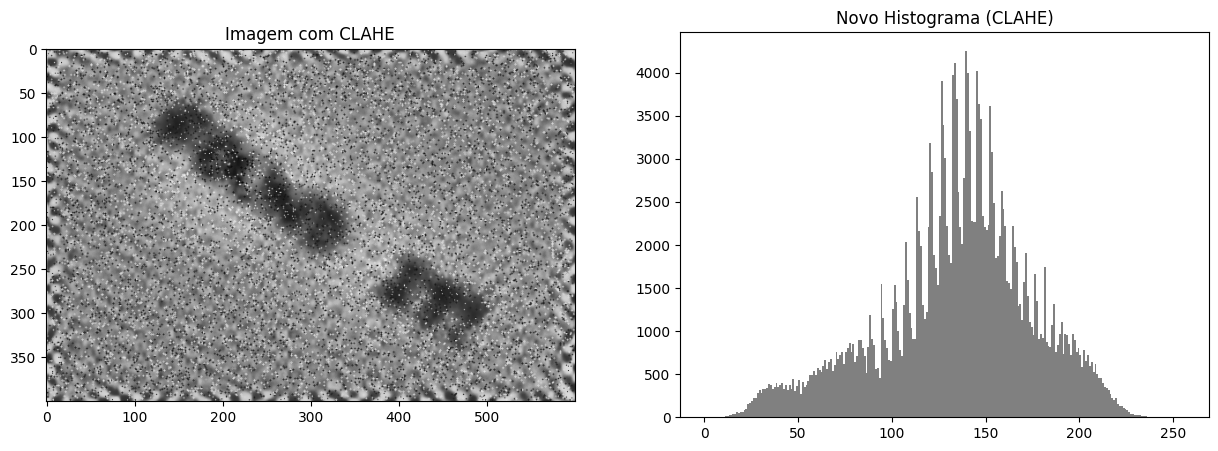

In [79]:
clahe = cv2.createCLAHE(clipLimit=CLAHE_CLIP_LIMIT, tileGridSize=CLAHE_TILE_GRID_SIZE)
img_contrast = clahe.apply(img_denoised)

# Guardar a imagem realçada
cv2.imwrite(os.path.join(OUTPUT_DIR, '3_contrast_enhanced.png'), img_contrast)

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1), plt.imshow(img_contrast, cmap='gray', vmin=0, vmax=255), plt.title('Imagem com CLAHE')
plt.subplot(1, 2, 2), plt.hist(img_contrast.ravel(), bins=256, range=[0,256], color='gray'), plt.title('Novo Histograma (CLAHE)')
plt.show()


## 7. Passo 4: Caminhos Paralelos de Segmentação
Uma vez resolvida a limpeza de imagem base, testamos em paralelo duas abordagens de segmentação:
**Opção A:** Binarização de imagem (para obter sólidos das letras).
**Opção B:** Extração unicamente de contornos (para obter o shape isolado).

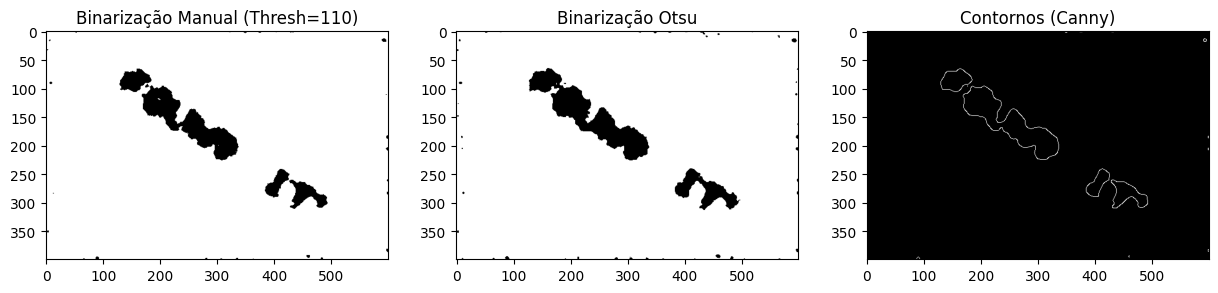

In [80]:
# === OPÇÃO A: Binarização ===
# === OPÇÃO A: Binarização ===
_, img_bin_manual = cv2.threshold(img_denoised, BIN_THRESH_VALUE, BIN_MAX_VALUE, cv2.THRESH_BINARY)
_, img_bin_otsu = cv2.threshold(img_denoised, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# --- NOVO PASSO: Limpeza do "Pó" ---
# Aplicamos um filtro de mediana pequeno (kernel=5) para apagar os pontinhos isolados
# sem destruir as bordas das letras grandes.
img_bin_manual = cv2.medianBlur(img_bin_manual, 5)
img_bin_otsu = cv2.medianBlur(img_bin_otsu, 5)
# -----------------------------------

cv2.imwrite(os.path.join(OUTPUT_DIR, '3a_binarized_manual.png'), img_bin_manual)
cv2.imwrite(os.path.join(OUTPUT_DIR, '3a_binarized_otsu.png'), img_bin_otsu)

# === OPÇÃO B: Contornos ===
img_bin_limpa = cv2.medianBlur(img_bin_manual, 7)
img_contours = cv2.Canny(img_bin_limpa, 100, 200)
cv2.imwrite(os.path.join(OUTPUT_DIR, '3b_contours.png'), img_contours)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1), plt.imshow(img_bin_manual, cmap='gray'), plt.title(f'Binarização Manual (Thresh={BIN_THRESH_VALUE})')
plt.subplot(1, 3, 2), plt.imshow(img_bin_otsu, cmap='gray'), plt.title('Binarização Otsu')
plt.subplot(1, 3, 3), plt.imshow(img_contours, cmap='gray'), plt.title(f'Contornos (Canny)')
plt.show()


## 8. Validação Extra: Extração de Texto com OCR
Para provar que o pipeline teve sucesso, submetemos a nossa imagem despoluída a um motor de OCR (Neste caso, Tesseract).
Se a máquina conseguir extrair as strings, provamos empiricamente o sucesso do projeto.

### Nota sobre o Tesseract OCR
A célula seguinte utiliza a biblioteca `pytesseract` para realizar o reconhecimento ótico de caracteres. É importante notar que `pytesseract` é um *wrapper* para o motor Tesseract OCR, o que significa que **o Tesseract precisa de estar instalado no teu sistema operativo** para que o código funcione.

Se o Tesseract não estiver instalado ou não estiver no `PATH` do sistema, a célula seguinte irá gerar um erro (`TesseractNotFoundError`).

**Instalação em Linux (Ubuntu/Debian):**
```bash
sudo apt update
sudo apt install tesseract-ocr
```

**Instalação em outros sistemas:**
Consulta o guia oficial de instalação do Tesseract.

In [81]:
if 'pytesseract' in globals():
    try:
        # O OCR geralmente tem a maior taxa de sucesso com texto preto sobre fundo branco.
        # Garantimos que a imagem submetida segue essa lógica. Se Otsu resultou num fundo escuro, invertemos os pixels.
        img_for_ocr = cv2.bitwise_not(img_bin_manual)
        
        # Page Segmentation Mode = 6 (Assumir um único bloco uniforme de texto)
        custom_config = r'--oem 3 --psm 6' 
        texto_reconhecido = pytesseract.image_to_string(img_for_ocr, config=custom_config)
        
        print("\n================ TEXTO DETETADO =================")
        print(texto_reconhecido.strip() if texto_reconhecido.strip() else "[Nenhum texto reconhecido, tenta afinar as variáveis K]")
        print("=================================================\n")

    except pytesseract.TesseractNotFoundError:
        print("\n!!!!!!!!!! ERRO TESSERACT !!!!!!!!!!!")
        print("O executável 'tesseract' não foi encontrado.")
        print("Verifica se o Tesseract OCR está instalado e no PATH do sistema.")
        print("Consulta a nota em Markdown acima para instruções de instalação.")
        print("!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!\n")
else:
    print("Validação de texto ignorada (pytesseract não disponível).")


Validação de texto ignorada (pytesseract não disponível).
